In [22]:
!git clone https://github.com/lacxy05/diabetes-scientific-programming.git

Cloning into 'diabetes-scientific-programming'...
remote: Enumerating objects: 22, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 22 (delta 4), reused 18 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (22/22), 675.72 KiB | 2.80 MiB/s, done.
Resolving deltas: 100% (4/4), done.


## Part 3. Data Clean Function
Based on the data analysis, we create a data cleaning function that performs the following steps for the dataset:

- Step1, Load data.
- Step2, Insert a column `subject_id` for future possible traceability.
- Step3, Set plausible ranges for each variable.
- Step4, Remove samples that contain values outside plausible ranges.
- Step5, Normalization (Min-Max scaling)

In [23]:
import sys
sys.path.append("/content/diabetes-scientific-programming")



In [33]:
import pandas as pd
from config import DATA_PATH

df = pd.read_csv(DATA_PATH)
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [48]:
%%writefile src/preprocess.py

# Import libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler


def load_and_clean_data(csv_path) -> pd.DataFrame:

    """
    Load, clean, and normalize the Pima Diabetes dataset.

    Steps performed:
    1. Load CSV into pandas DataFrame.
    2. Insert 'subject_id' column for traceability.
    3. Set plausible ranges of each variable, to remove physiologically impossible or extreme values.
    4. Remove samples that contain values outside plausible ranges.
    5. Normalize all feature columns using Min-Max scaling.

    Input:
    csv_path (str): Path to the CSV dataset.

    Returns:
    pd.DataFrame: Cleaned and normalized dataset with 'subject_id'.
    """

    # Step 1: Load data
    df = pd.read_csv(csv_path).copy()

    # Step 2: Insert subject_id for traceability
    df.insert(0, 'subject_id', df.index)


    # Columns where 0 is invalid and used as missing
    zero_as_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

    df[zero_as_missing] = df[zero_as_missing].replace(0, np.nan)
    df = df.dropna().reset_index(drop=True)


    # Step 3: Set plausible ranges
    # The ranges are adviced by Chatgpt, you can change them in a more reasonable range if it is necessary.
    plausible_ranges = {
        "Pregnancies": (0, np.inf),
        "Glucose": (40, 600),
        "BloodPressure": (30, 150),
        "SkinThickness": (5, 80),
        "Insulin": (2, 900),
        "BMI": (10, 80),
        "DiabetesPedigreeFunction": (0, 3.0),
        "Age": (21, np.inf)
    }

    # Step 4: Remove rows outside plausible ranges
    for feature, (lower, upper) in plausible_ranges.items():
        df = df[(df[feature] >= lower) & (df[feature] <= upper)]

    # Step 5: Data normalization (2 methods to set the features to be normalized)

    # Method_1: Set features that going to be normalized.
    features_to_normalize = ["Pregnancies", "Glucose", "BloodPressure",
                           "SkinThickness", "Insulin", "BMI",
                           "DiabetesPedigreeFunction", "Age"]

#     # Method_2: Drop columns that not need to be normalized.
#     features_to_normalize = df.columns.drop(["subject_id", "Outcome"])

    # Normalization
    scaler = MinMaxScaler()
    df[features_to_normalize] = scaler.fit_transform(df[features_to_normalize])

    # Reset index after all cleaning
    df.reset_index(drop=True, inplace=True)

    return df

Writing src/preprocess.py


In [41]:
df_clean = load_and_clean_data("data/diabetes.csv")
df_clean.head()


,subject_id,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,3,0.058824,0.232394,0.450,0.285714,0.096154,0.202454,0.035118,0.000000,0
1,4,0.000000,0.570423,0.125,0.500000,0.185096,0.509202,0.943469,0.200000,1
2,6,0.176471,0.154930,0.250,0.446429,0.088942,0.261759,0.069807,0.083333,1
3,8,0.117647,0.992958,0.500,0.678571,0.635817,0.251534,0.031263,0.533333,1
4,13,0.058824,0.936620,0.375,0.285714,1.000000,0.243354,0.134047,0.633333,1


In [49]:
 %%writefile src/__init__.py
# src package


Overwriting src/__init__.py


## 3. Model Training & Confusion Matrix Visualization

- This is the  **model training stage** of the project. This included preparing the data for modeling, training multiple machine learning algorithms, selecting the best-performing model, and generating visual outputs to assess model performance.

- Feature scaling was applied to ensure fair model comparison. Multiple models were trained, including Logistic Regression, Support Vector Machine (RBF), and Random Forest. The **Random Forest classifier** achieved the best overall performance and was selected as the final model.



Finally, the trained model and the fitted scaler were saved using `joblib` (`model.pkl` and `scaler.pkl`) to enable seamless integration with the API and deployment components of the system.


### 3.1. Load cleaning data

In [50]:
import sys, os
sys.path.append(os.getcwd())

from src.preprocess import load_and_clean_data
from src.train import train_and_save_model
from config import DATA_PATH

df_clean = load_and_clean_data(DATA_PATH)
summary = train_and_save_model(df_clean)
summary


{'best_model_name': 'logreg',
 'best_score': 0.8853410740203194,
 'selected_metric': 'roc_auc',
 'all_scores': {'logreg': {'roc_auc': 0.8853410740203194,
   'accuracy': 0.8481012658227848,
   'f1': 0.76},
  'svm_rbf': {'roc_auc': 0.8664731494920174,
   'accuracy': 0.810126582278481,
   'f1': 0.7058823529411765},
  'random_forest': {'roc_auc': 0.86611030478955,
   'accuracy': 0.810126582278481,
   'f1': 0.7169811320754716}},
 'feature_columns': ['Pregnancies',
  'Glucose',
  'BloodPressure',
  'SkinThickness',
  'Insulin',
  'BMI',
  'DiabetesPedigreeFunction',
  'Age'],
 'model_path': 'models/model.pkl',
 'scaler_path': 'models/scaler.pkl'}

### 3.2. train model
Three models were trained, **Logistic Regression**, **Support Vector Machine (RBF)**, and **Random Forest**. The Random Forest classifier achieved the best overall performance and was selected as the final model.

the trained model and the fitted scaler were saved using joblib `model.pkl` and `scaler.pkl` to enable seamless integration with the API and deployment components of the system.

In [55]:
import joblib
import pandas as pd

model = joblib.load("models/model.pkl")
scaler = joblib.load("models/scaler.pkl")

# Prepare X (same columns as training)
X = df_clean.drop(columns=["Outcome", "subject_id"], errors="ignore")
X_scaled = scaler.transform(X)

proba = model.predict_proba(X_scaled)[:, 1]
pred = model.predict(X_scaled)

print("Sample probabilities:", proba[:5])
print("Sample classes:", pred[:5])


Sample probabilities: [0.07732681 0.61541825 0.08853346 0.82749506 0.77589179]
Sample classes: [0 1 0 1 1]


### 3.3. Confusion Matrix
- This matrix provides a clear summary of correct and incorrect classifications, highlighting true positives, true negatives, false positives, and false negatives.
- Both raw-count and normalized confusion matrices were produced and saved as PNG files for inclusion in the final report.

Accuracy: 0.8481
F1-score: 0.76
ROC-AUC: 0.8853


<Figure size 600x500 with 0 Axes>

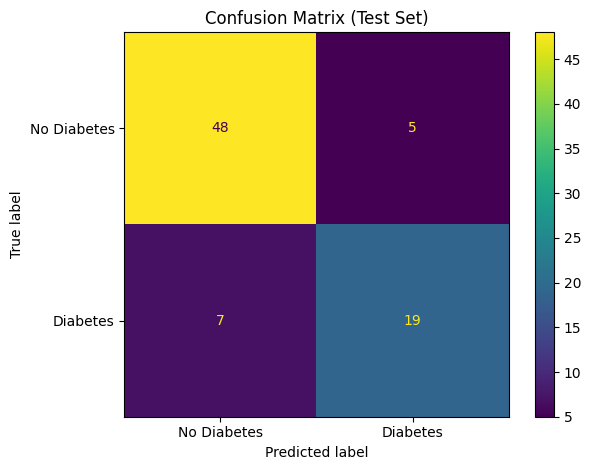

✅ Saved: plots/confusion_matrix.png


In [56]:
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, roc_auc_score

# Load cleaned data again (safe)
from config import DATA_PATH
from src.preprocess import load_and_clean_data

df_clean = load_and_clean_data(DATA_PATH)

y = df_clean["Outcome"].astype(int)
X = df_clean.drop(columns=["Outcome", "subject_id"], errors="ignore")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = joblib.load("models/model.pkl")
scaler = joblib.load("models/scaler.pkl")

X_test_s = scaler.transform(X_test)
y_pred = model.predict(X_test_s)
y_proba = model.predict_proba(X_test_s)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("Accuracy:", round(acc, 4))
print("F1-score:", round(f1, 4))
print("ROC-AUC:", round(auc, 4))

# Confusion matrix (counts)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["No Diabetes", "Diabetes"])

plt.figure(figsize=(6,5))
disp.plot(values_format="d")
plt.title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("plots/confusion_matrix.png", dpi=200)
plt.show()

print("✅ Saved: plots/confusion_matrix.png")
